# Q2: SVM Classification on Mobile Price Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Load data
df = pd.read_csv('data/mobile_price.csv')
print(f"Dataset shape: {df.shape}")
print(f"Price range distribution:\n{df['price_range'].value_counts().sort_index()}")
df.head()

Dataset shape: (2000, 21)
Price range distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 2(a) Train SVM with C=1.0, report accuracy and F1-score

In [2]:
# Split data: 60% train, 20% validation, 20% test
X = df.drop('price_range', axis=1).values
y = df['price_range'].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
# 0.25 * 0.8 = 0.2 of total

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 1200, Val: 400, Test: 400


In [3]:
# Train SVM with C=1.0
clf = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# Evaluate on train, validation, and test sets
# Using macro averaging for F1 (4-class problem)
print("=== SVM with C=1.0 ===")
print(f"{'Set':<12} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 36)
for name, X_set, y_set in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_pred = clf.predict(X_set)
    acc = accuracy_score(y_set, y_pred)
    f1 = f1_score(y_set, y_pred, average='macro')
    print(f"{name:<12} {acc:>10.4f} {f1:>12.4f}")

=== SVM with C=1.0 ===
Set            Accuracy   F1 (macro)
------------------------------------
Train            0.9500       0.9505
Validation       0.9475       0.9463
Test             0.9625       0.9617


## 2(b) Explore different values of C and visualize performance

In [4]:
# Sweep C values
C_values = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000]

results = []
for C in C_values:
    svc = SVC(C=C, kernel='rbf', gamma='scale', random_state=42)
    svc.fit(X_train, y_train)
    
    row = {'C': C}
    for name, X_set, y_set in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
        y_pred = svc.predict(X_set)
        row[f'{name}_acc'] = accuracy_score(y_set, y_pred)
        row[f'{name}_f1'] = f1_score(y_set, y_pred, average='macro')
    results.append(row)
    print(f"C={C:>8} done")

results_df = pd.DataFrame(results)
results_df

C=   0.001 done


C=    0.01 done


C=     0.1 done
C=     1.0 done
C=      10 done


C=     100 done
C=    1000 done
C=   10000 done


,C,train_acc,train_f1,val_acc,val_f1,test_acc,test_f1
0,0.001,0.262500,0.103960,0.2325,0.094320,0.2300,0.093496
1,0.010,0.324167,0.218165,0.3075,0.224865,0.3000,0.211054
2,0.100,0.894167,0.895939,0.8950,0.894865,0.9000,0.898654
3,1.000,0.950000,0.950473,0.9475,0.946321,0.9625,0.961672
4,10.000,0.969167,0.969639,0.9450,0.944181,0.9700,0.969295
5,100.000,0.977500,0.977829,0.9550,0.954316,0.9700,0.969557
6,1000.000,0.986667,0.986839,0.9500,0.948807,0.9700,0.969212
7,10000.000,0.997500,0.997527,0.9400,0.938914,0.9700,0.969718


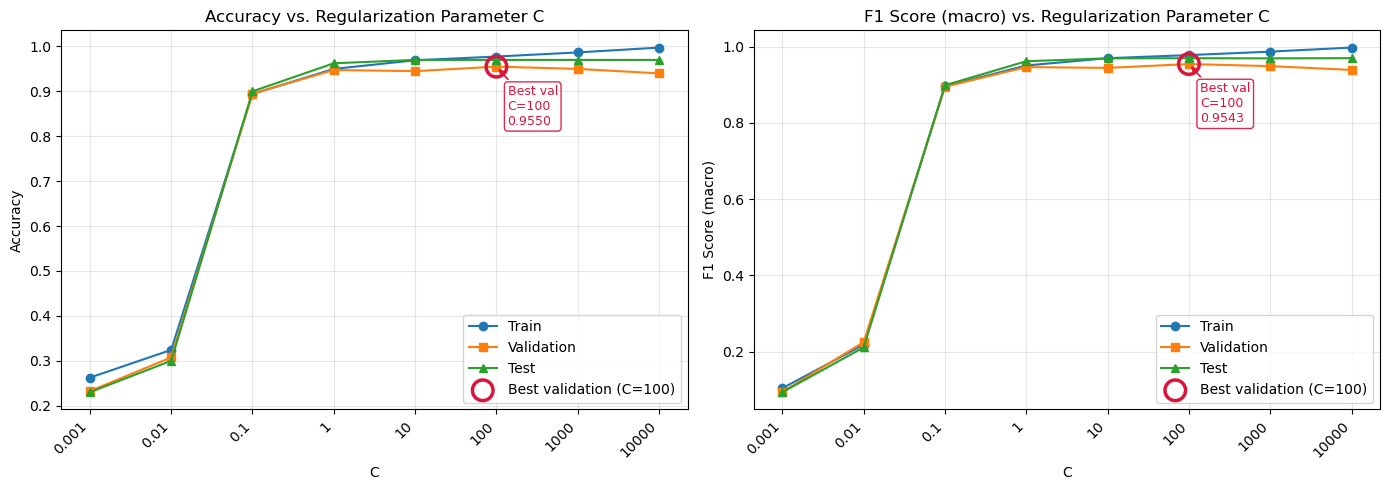

In [5]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.log10(results_df['C'])
tick_labels = [f'{c:g}' for c in results_df['C']]

for ax, metric, label in zip(axes, ['acc', 'f1'], ['Accuracy', 'F1 Score (macro)']):
    ax.plot(x, results_df[f'train_{metric}'], 'o-', label='Train')
    ax.plot(x, results_df[f'val_{metric}'], 's-', label='Validation')
    ax.plot(x, results_df[f'test_{metric}'], '^-', label='Test')

    best_val_idx = results_df[f'val_{metric}'].idxmax()
    best_val_x = x.iloc[best_val_idx]
    best_val_y = results_df.loc[best_val_idx, f'val_{metric}']
    best_val_C = results_df.loc[best_val_idx, 'C']
    ax.scatter(best_val_x, best_val_y, s=220, facecolors='none', edgecolors='crimson',
               linewidths=2.5, zorder=6, label=f'Best validation (C={best_val_C:g})')
    ax.annotate(f'Best val\nC={best_val_C:g}\n{best_val_y:.4f}',
                xy=(best_val_x, best_val_y), xytext=(8, -42), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2),
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='crimson', alpha=0.9),
                fontsize=9, color='crimson')
    ax.set_xlabel('C')
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs. Regularization Parameter C')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('report/figures/q2_svm_c_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 2(c) Best generalization performance

In [6]:
# Find best C based on validation accuracy
best_idx = results_df['val_acc'].idxmax()
best_C = results_df.loc[best_idx, 'C']

print(f"Best C (by validation accuracy): {best_C}")
print(f"  Train  - Accuracy: {results_df.loc[best_idx, 'train_acc']:.4f}, F1: {results_df.loc[best_idx, 'train_f1']:.4f}")
print(f"  Val    - Accuracy: {results_df.loc[best_idx, 'val_acc']:.4f}, F1: {results_df.loc[best_idx, 'val_f1']:.4f}")
print(f"  Test   - Accuracy: {results_df.loc[best_idx, 'test_acc']:.4f}, F1: {results_df.loc[best_idx, 'test_f1']:.4f}")
print()
print("Full results table:")
results_df.to_csv('results/q2_svm_results.csv', index=False)
results_df

Best C (by validation accuracy): 100.0
  Train  - Accuracy: 0.9775, F1: 0.9778
  Val    - Accuracy: 0.9550, F1: 0.9543
  Test   - Accuracy: 0.9700, F1: 0.9696

Full results table:


,C,train_acc,train_f1,val_acc,val_f1,test_acc,test_f1
0,0.001,0.262500,0.103960,0.2325,0.094320,0.2300,0.093496
1,0.010,0.324167,0.218165,0.3075,0.224865,0.3000,0.211054
2,0.100,0.894167,0.895939,0.8950,0.894865,0.9000,0.898654
3,1.000,0.950000,0.950473,0.9475,0.946321,0.9625,0.961672
4,10.000,0.969167,0.969639,0.9450,0.944181,0.9700,0.969295
5,100.000,0.977500,0.977829,0.9550,0.954316,0.9700,0.969557
6,1000.000,0.986667,0.986839,0.9500,0.948807,0.9700,0.969212
7,10000.000,0.997500,0.997527,0.9400,0.938914,0.9700,0.969718


## Best-C test confusion matrix

Best-C test confusion matrix (rows=true labels, columns=predicted labels):
[[102   3   0   0]
 [  1  90   0   0]
 [  0   2  89   1]
 [  0   0   5 107]]


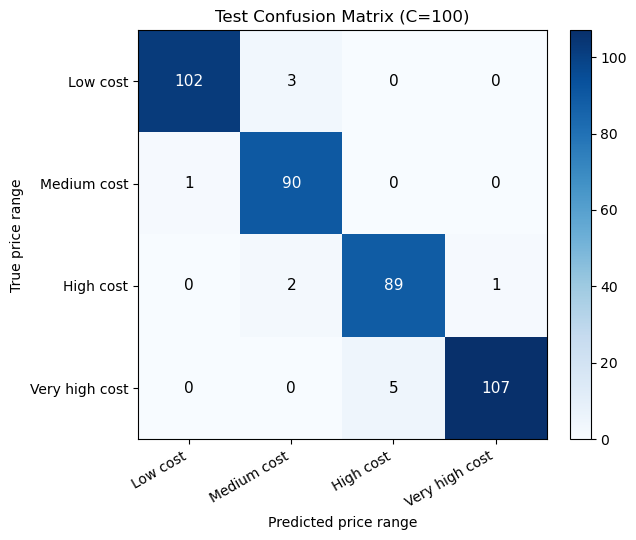

In [7]:
# Class-level error analysis for the validation-selected model
best_svc = SVC(C=best_C, kernel='rbf', gamma='scale', random_state=42)
best_svc.fit(X_train, y_train)
y_test_pred = best_svc.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2, 3])
class_names = ['Low cost', 'Medium cost', 'High cost', 'Very high cost']

print('Best-C test confusion matrix (rows=true labels, columns=predicted labels):')
print(cm)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'Test Confusion Matrix (C={best_C:g})')
ax.set_xlabel('Predicted price range')
ax.set_ylabel('True price range')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=11)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('report/figures/q2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 2(c) Observations

**Note:** F1-score is computed using `macro` averaging across all 4 classes throughout this question.

**Underfitting at small C:** When C is very small (0.001, 0.01), the SVM heavily penalizes the model complexity, resulting in a very restrictive decision boundary. This leads to severe underfitting — both training and validation accuracy are extremely low (23–32%), barely above random chance (25% for 4 classes).

**Training improves after C=100, but validation declines:** After C=100, training accuracy keeps increasing from 97.75% to 98.67% and then 99.75%, but validation accuracy drops from 95.5% to 95.0% and then 94.0%. This widening train-validation gap is a classic overfitting signal.